# Zomato-Restaurants-Rating-Prediction 

# 1. Data Cleaning

In [1]:
## importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import os
# os.chdir()
os.chdir(path = "/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction" )
print(os.getcwd())


/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction


In [3]:
## loading the Zomato dataset

df = pd.read_csv("raw data/zomato.csv")

In [4]:
# check for duplicate values
print("No of Duplicates in dataset:  ", df.duplicated().sum())
df.shape

No of Duplicates in dataset:   0


(51717, 17)

In [5]:
# drop the duplicates
df.drop_duplicates(inplace=True)
df.shape

(51717, 17)

In [6]:
df.shape

(51717, 17)

setting option to show all columns of the dataset

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)

In [8]:
df.head(3)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [9]:
df.tail(3)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield
51716,https://www.zomato.com/bangalore/the-nest-the-...,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4 /5,13,+91 8071117272,"ITPL Main Road, Whitefield","Bar, Casual Dining",NaN,"Finger Food, North Indian, Continental","1,500","[('Rated 5.0', 'RATED\n Great ambience , look...",[],Pubs and bars,Whitefield


In [10]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [11]:
df.dtypes

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object

In [12]:
df.count()

url                            51717
address                        51717
name                           51717
online_order                   51717
book_table                     51717
rate                           43942
votes                          51717
phone                          50509
location                       51696
rest_type                      51490
dish_liked                     23639
cuisines                       51672
approx_cost(for two people)    51371
reviews_list                   51717
menu_item                      51717
listed_in(type)                51717
listed_in(city)                51717
dtype: int64

In [13]:
# check for duplicate values
print("No of Duplicates in dataset:  ",df.duplicated().sum())

No of Duplicates in dataset:   0


In [14]:
## Checking for Null
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [15]:
df.shape

(51717, 17)

In [16]:
## deleting unnecessary columns->

df= df.drop(columns=['url', 'phone'],axis=1)

In [17]:
df = df.drop(columns=['address'], axis=1)

In [18]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [19]:
# check for duplicate values
print("No of Duplicates in dataset:  ",df.duplicated().sum())

No of Duplicates in dataset:   63


In [20]:
df.drop_duplicates(inplace=True)

In [21]:
print("No of Duplicates in dataset:  ",df.duplicated().sum())


No of Duplicates in dataset:   0


In [22]:
## Printing the null values for each column in percentage
missing_percent = np.round(df.isnull().sum()/len(df)*100,2)
print(f"% Data Missing -> \n {missing_percent}")

% Data Missing -> 
 name                            0.00
online_order                    0.00
book_table                      0.00
rate                           15.02
votes                           0.00
location                        0.04
rest_type                       0.44
dish_liked                     54.26
cuisines                        0.09
approx_cost(for two people)     0.67
reviews_list                    0.00
menu_item                       0.00
listed_in(type)                 0.00
listed_in(city)                 0.00
dtype: float64


In [23]:
for col in df.columns:
    if missing_percent[col] > 0:
        print(f'missing percent in {col}    : {missing_percent[col]}%')

missing percent in rate    : 15.02%
missing percent in location    : 0.04%
missing percent in rest_type    : 0.44%
missing percent in dish_liked    : 54.26%
missing percent in cuisines    : 0.09%
missing percent in approx_cost(for two people)    : 0.67%


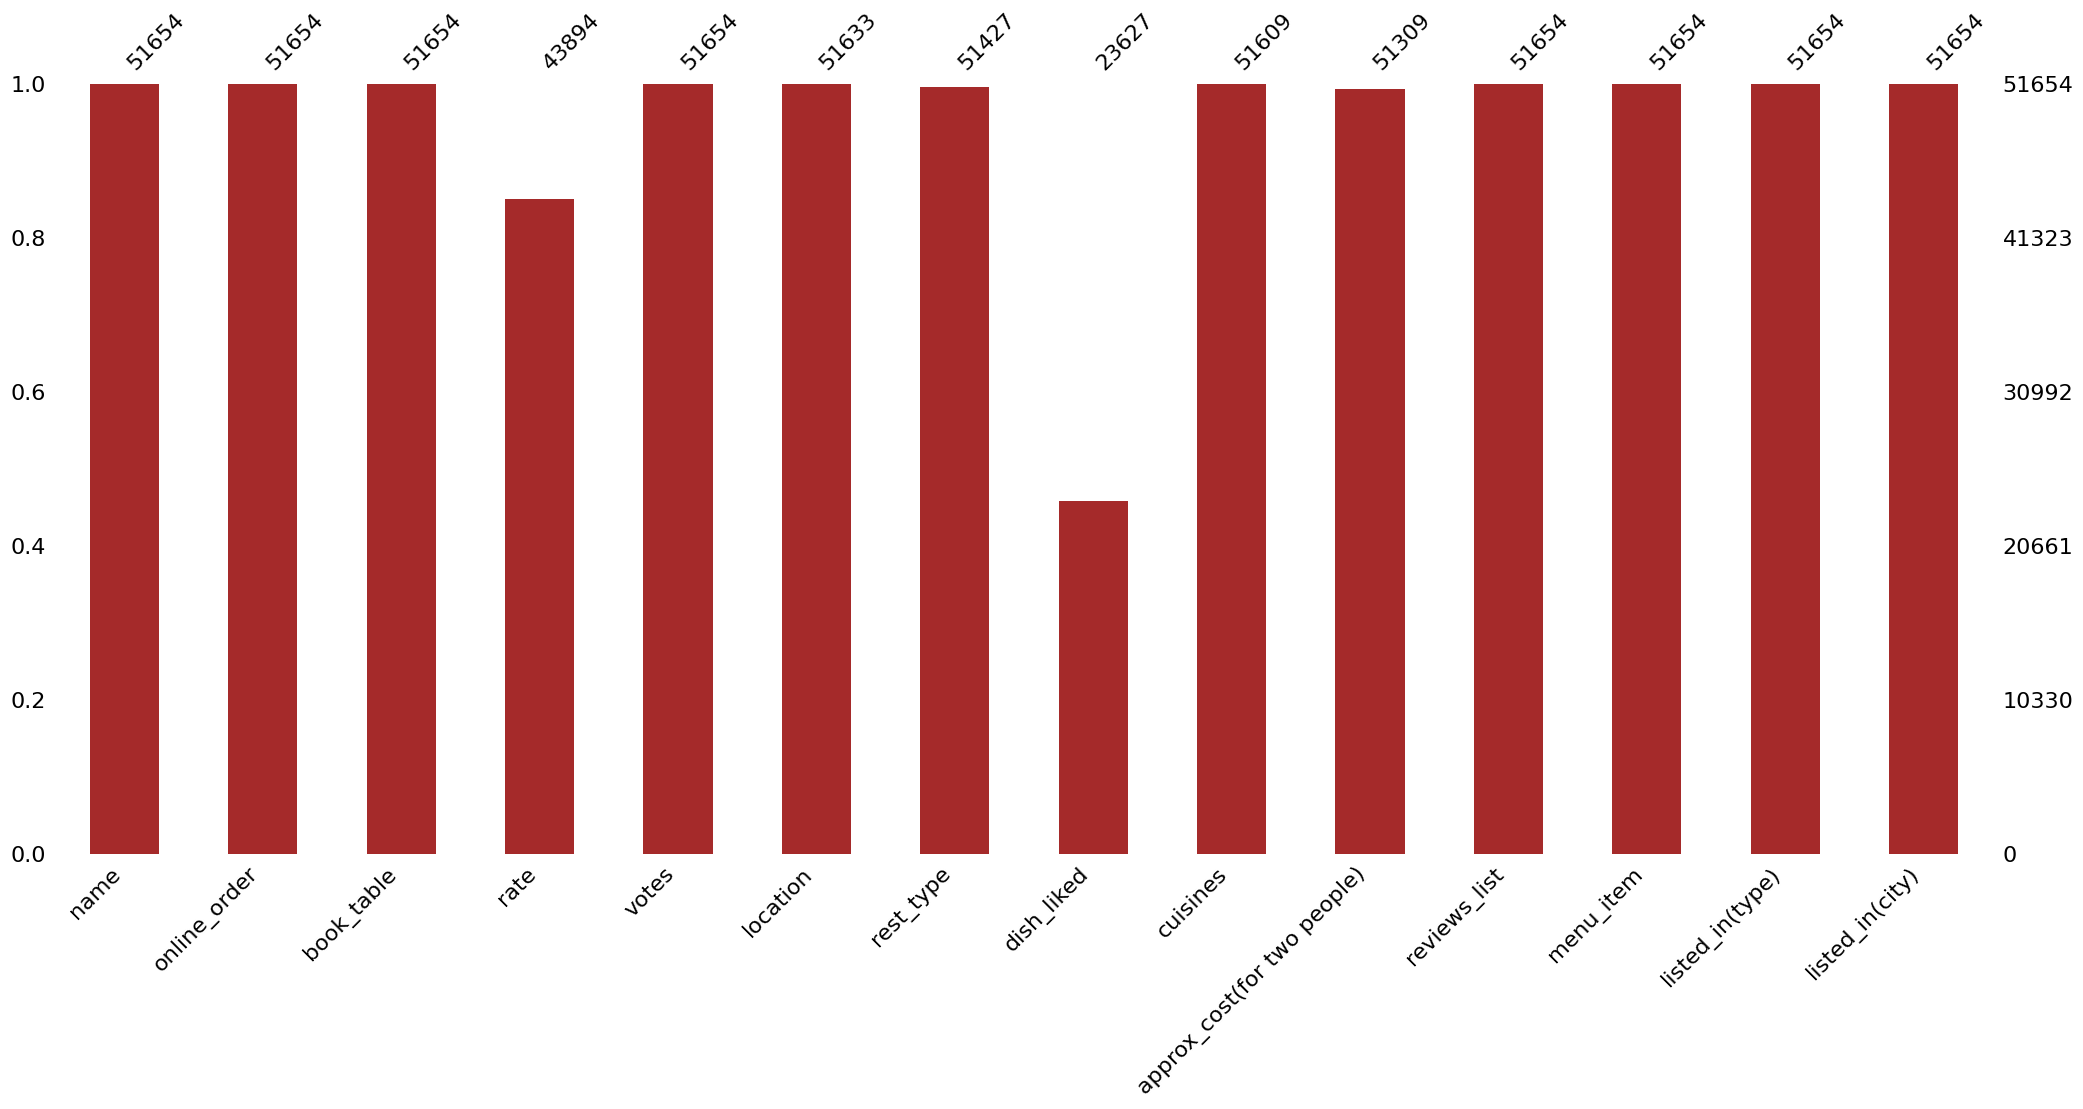

In [24]:
import missingno as msno
msno.bar(df,color='brown')
plt.show("missing no histogram")

In [25]:
for col in df.columns:
    if missing_percent[col] > 0:
        print(f'missing percent in {col}    : {missing_percent[col]}%')

missing percent in rate    : 15.02%
missing percent in location    : 0.04%
missing percent in rest_type    : 0.44%
missing percent in dish_liked    : 54.26%
missing percent in cuisines    : 0.09%
missing percent in approx_cost(for two people)    : 0.67%


In [26]:
# check for duplicate values
print("No of Duplicates in dataset:  ",df.duplicated().sum())

No of Duplicates in dataset:   0


## Handling NaN values

In [27]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [28]:
# removed 'NEW' and '-' from rate coloumn and put NaN value.
df['rate'] = df['rate'].replace('NEW',np.nan)
df['rate'] = df['rate'].replace('-',np.nan)

In [29]:
## we can save data points in 'rate' column by imputing the ratings from "review" column

df['rate'].isna().sum()

np.int64(10027)

In [30]:
## apply takes a function and applies it to all values of pandas series.

df['rate'] = df['rate'].astype(str)

## removed all '/5' and replace with ''
df['rate'] = df['rate'].apply(lambda r: r.replace('/5',''))

In [31]:
## convert rate to float
df['rate'] = df['rate'].apply(lambda r: float(r))

In [32]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [33]:
df['rate'].head(2)

0    4.1
1    4.1
Name: rate, dtype: float64

In [34]:
# return to a list of tuples
import ast
df.reviews_list = df.reviews_list.apply(lambda x: ast.literal_eval(x))

type(df.reviews_list[0])

list

In [35]:
((df.isna().sum()/df.shape[0])*100).round(2)

name                            0.00
online_order                    0.00
book_table                      0.00
rate                           19.41
votes                           0.00
location                        0.04
rest_type                       0.44
dish_liked                     54.26
cuisines                        0.09
approx_cost(for two people)     0.67
reviews_list                    0.00
menu_item                       0.00
listed_in(type)                 0.00
listed_in(city)                 0.00
dtype: float64

In [36]:
def extract_features_from_review_list(x):
    '''
    extract the rate value out of a string inside tuple 
    '''
    # ensure that x is not Null and there is more than one rate
    if not x or len(x) <= 1:
        return None
    
    ## checked give values is text or not, if it is text then removed 'Rated', convert string to float.
    rate = [float(i[0].replace('Rated','').strip())  for i in x if type(i[0])== str]
    
    ## return average value
    return round((sum(rate)/len(rate)),1)

In [37]:
df['reviews_list'].head(2)

0    [(Rated 4.0, RATED\n  A beautiful place to din...
1    [(Rated 4.0, RATED\n  Had been here for dinner...
Name: reviews_list, dtype: object

In [38]:
# check for the second item in list
df.reviews_list[0][1]

('Rated 4.0',
 'RATED\n  I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\nCheers')

- we will use this part '('Rated 4.0',)' of the review_list column to fill in 'rate' columns "NA"


In [39]:
extracted = [float(i[0].replace('Rated','').strip()) for i in df.reviews_list[0]]
extracted

[4.0, 4.0, 2.0, 4.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0]

In [40]:
## calculating its mean for imputation
extracted_mean = round((sum(extracted)/len(extracted)),1)
extracted_mean

4.1

In [41]:
# create new column
df['review_rate']  = df.reviews_list.apply(lambda x : extract_features_from_review_list(x))

- Nailed it, we saved around 7000+ rows of our dataset

In [42]:
print("Extracted Rate: ",extracted_mean)
print("Original Rate: ",df.rate[0])

Extracted Rate:  4.1
Original Rate:  4.1


In [43]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)',
       'review_rate'],
      dtype='object')

In [44]:
## CLeaning "rate" column
# df.head(2)
df.shape

(51654, 15)

In [45]:

## Compare "Original Rate" vs "Rate extracted from Review List"
df.loc[:,['rate','review_rate']].sample(10)

,rate,review_rate
43657,NaN,NaN
41806,3.1,1.0
8513,3.7,3.6
40850,3.2,5.0
50386,4.1,3.6
19080,3.9,3.9
7284,NaN,NaN
30421,NaN,NaN
22730,3.0,2.0
26806,3.8,1.7


In [46]:
## Rate column -> 15% nan value
print(df['rate'].unique())


[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 nan 2.9 3.5
 2.6 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]


In [47]:
df['rate'].isna().sum()

np.int64(10027)

In [48]:
## finding rate = NaN and review_rate == not NaN
df.query('rate != rate & review_rate == review_rate')[:5]

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),review_rate
72,Spicy Tandoor,No,No,NaN,0,Banashankari,Quick Bites,NaN,North Indian,150,"[(Rated 4.0, RATED\n cost for chicken rolls i...",[],Delivery,Banashankari,4.5
90,Me And My Cake,No,No,NaN,0,Banashankari,Delivery,NaN,"Bakery, Desserts",500,"[(Rated 1.0, RATED\n Do not order anything. T...",[],Delivery,Banashankari,1.0
110,Hari Super Sandwich,No,No,NaN,0,Banashankari,"Takeaway, Delivery",NaN,"Sandwich, Pizza, Beverages",200,"[(Rated 1.0, RATED\n I have been here many ti...",[],Delivery,Banashankari,1.0
116,Wood Stove,No,No,NaN,0,Banashankari,"Takeaway, Delivery",NaN,South Indian,150,"[(Rated 5.0, RATED\n Wow this food is great ?...",[],Delivery,Banashankari,5.0
138,Sri Murari Family Restaurant,No,No,NaN,0,Banashankari,Quick Bites,NaN,Biryani,250,"[(Rated 4.0, RATED\n This tiny mess near kath...",[],Delivery,Banashankari,4.5


In [49]:

## finding index where rate==NaN and review_rate== not NaN
nan_index = df.query('rate != rate & review_rate == review_rate').index
for i in nan_index:
    df.loc[i,'rate'] = df.loc[i,'review_rate'] 

In [50]:
# update the number of null values now
df.rate.isna().sum()

np.int64(8522)

- saved around 1000 data points

In [51]:
# check now
((df.isna().sum()/df.shape[0])*100).round(2)

name                            0.00
online_order                    0.00
book_table                      0.00
rate                           16.50
votes                           0.00
location                        0.04
rest_type                       0.44
dish_liked                     54.26
cuisines                        0.09
approx_cost(for two people)     0.67
reviews_list                    0.00
menu_item                       0.00
listed_in(type)                 0.00
listed_in(city)                 0.00
review_rate                    31.15
dtype: float64

In [52]:
print(df['rate'].unique())

[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 4.5 2.9 nan
 3.5 1.  2.6 3.4 5.  2.5 2.7 2.  4.7 4.8 1.8 2.4 2.2 2.3 4.9 2.1 1.5 1.3
 1.4 1.2 1.6 1.9 1.7]


In [53]:
# # first let's drop the review_rate column now
df.drop(columns='review_rate',axis=1,inplace=True)

In [54]:

# drop null values
df.dropna(subset=['rate', 'approx_cost(for two people)'],inplace=True)

In [55]:
df.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
location                           0
rest_type                        147
dish_liked                     19394
cuisines                           8
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [56]:
df.shape

(42854, 14)

In [57]:
# remove cuisines missing values
df=df[df.cuisines.isna()==False]

In [58]:

## rename 'approx_cost(for two people)' to 'average_cost'
df.rename(columns={'approx_cost(for two people)': 'average_cost'}, inplace=True)

In [59]:
# check for percentage of null values 
((df.isna().sum()/df.shape[0])*100).round(2)

name                0.00
online_order        0.00
book_table          0.00
rate                0.00
votes               0.00
location            0.00
rest_type           0.34
dish_liked         45.25
cuisines            0.00
average_cost        0.00
reviews_list        0.00
menu_item           0.00
listed_in(type)     0.00
listed_in(city)     0.00
dtype: float64

In [60]:
df = df.drop(columns='dish_liked', axis=1)

In [61]:
((df.isna().sum()/df.shape[0])*100).round(2)

name               0.00
online_order       0.00
book_table         0.00
rate               0.00
votes              0.00
location           0.00
rest_type          0.34
cuisines           0.00
average_cost       0.00
reviews_list       0.00
menu_item          0.00
listed_in(type)    0.00
listed_in(city)    0.00
dtype: float64

In [62]:
# drop nan 
df.dropna(how='any', inplace=True)
df.isna().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
average_cost       0
reviews_list       0
menu_item          0
listed_in(type)    0
listed_in(city)    0
dtype: int64

In [63]:
df.shape

(42699, 13)

In [64]:
df.head(2)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,average_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[(Rated 4.0, RATED\n Had been here for dinner...",[],Buffet,Banashankari


In [65]:
# lets check the NULL values in Reviews_list column
print("NULL values : ",df['menu_item'].isnull().sum())
print("Blank : ", (df['menu_item']=="[]").sum())  # 25988 reviews_list are just empty rows

NULL values :  0
Blank :  31430


Note: We have a lot of blank values in the menu_item column, we'll probably drop this column later

In [66]:
df[df['menu_item']!="[]"].head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,average_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
32,Sweet Truth,Yes,No,3.9,35,Banashankari,Delivery,"Bakery, Desserts",500,"[(Rated 4.0, RATED\n I had the opportunity to...","['Chocolate Fantasy (Pack Of 5)', 'Pan Cake (P...",Delivery,Banashankari
34,Faasos,Yes,No,4.2,415,Banashankari,Quick Bites,"North Indian, Biryani, Fast Food",500,"[(Rated 3.0, RATED\n Not worth for the money ...","['Chole Kulcha Meal', 'Upvas Aloo Paratha With...",Delivery,Banashankari
39,Maruthi Davangere Benne Dosa,Yes,No,4.0,17,Banashankari,Quick Bites,South Indian,150,"[(Rated 5.0, RATED\n This restaurant serves t...","['Benne Dosa', 'Benne Masala Dosa', 'Benne Kal...",Delivery,Banashankari
46,Kitchen Garden,Yes,No,3.6,244,Kumaraswamy Layout,Quick Bites,"North Indian, Chinese",300,"[(Rated 3.0, RATED\n We ordered two Indian ve...","['3 Poori with Subji', 'Chole Bhature [2 Piece...",Delivery,Banashankari
47,Recipe,Yes,No,4.0,804,Kumaraswamy Layout,Casual Dining,"North Indian, Chinese, Biryani, Rolls",450,"[(Rated 3.0, RATED\n Ordered Paneer meal via ...","['Veg Fried Rice', 'Egg Fried Rice', 'Chicken ...",Delivery,Banashankari


In [67]:
## Overview Rough)
df['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Dessert Parlor, Sweet Shop', 'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites', 'Kiosk', 'Food Truck',
       'Quick Bites, Dessert Parlor', 'Beverage Shop, Quick Bites',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Microbrewery, Casual Dining', 'Lounge',
       'Bar, Casual Dining', 'Food Court', 'Cafe, Bakery', 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Quick Bites, Beverage Shop',
       'Pub, Bar', 'Casual Dining, Pub', 'Lounge, Bar',
       'Dessert Parlor, Quick Bites', 'Food Court, 

- fortunately, the scraped data has clean values in this column "rest_type"

In [68]:
df['location'].tail()

51709                    Whitefield
51711                    Whitefield
51712                    Whitefield
51715    ITPL Main Road, Whitefield
51716    ITPL Main Road, Whitefield
Name: location, dtype: object

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42699 entries, 0 to 51716
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             42699 non-null  object 
 1   online_order     42699 non-null  object 
 2   book_table       42699 non-null  object 
 3   rate             42699 non-null  float64
 4   votes            42699 non-null  int64  
 5   location         42699 non-null  object 
 6   rest_type        42699 non-null  object 
 7   cuisines         42699 non-null  object 
 8   average_cost     42699 non-null  object 
 9   reviews_list     42699 non-null  object 
 10  menu_item        42699 non-null  object 
 11  listed_in(type)  42699 non-null  object 
 12  listed_in(city)  42699 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 4.6+ MB


In [70]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

### Final NaN Check->


In [71]:
df.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
average_cost       0
reviews_list       0
menu_item          0
listed_in(type)    0
listed_in(city)    0
dtype: int64

In [72]:
df.dtypes

name                object
online_order        object
book_table          object
rate               float64
votes                int64
location            object
rest_type           object
cuisines            object
average_cost        object
reviews_list        object
menu_item           object
listed_in(type)     object
listed_in(city)     object
dtype: object

### Data is cleaned and ready for Preprocessing and Feature Engineering

### Saving the cleaned data

In [73]:
import os
import joblib

# Always save relative to project root
base_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) if "__file__" in globals() else os.getcwd()
save_path = os.path.join(base_dir, "artifacts", "cleaned_data.pkl")

os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(df, save_path)

print(f"✅ Cleaned data saved successfully at: {save_path}")


✅ Cleaned data saved successfully at: /Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/cleaned_data.pkl
